# AirBnB
https://insideairbnb.com/get-the-data/

https://data.insideairbnb.com/brazil/rj/rio-de-janeiro/2025-12-28/data/listings.csv.gz

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../listings.csv')

In [3]:
df.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,821198084644106078,https://www.airbnb.com/rooms/821198084644106078,20250926170004,2025-09-27,city scrape,Bright and Peaceful Leblon Loft,Welcome! Come relax in our bright and stylish ...,Beautiful tree lined street just 3 blocks from...,https://a0.muscache.com/pictures/hosting/Hosti...,84350716,...,4.94,4.99,4.85,NaN,f,1,1,0,0,2.72
1,821198370698658112,https://www.airbnb.com/rooms/821198370698658112,20250926170004,2025-09-27,city scrape,Copacabana 100% reformado.,Guarantee of a safe and quality stay! <br /><...,"Copacabana, in the part near the neighborhood ...",https://a0.muscache.com/pictures/miso/Hosting-...,4347269,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
2,821200521820144734,https://www.airbnb.com/rooms/821200521820144734,20250926170004,2025-09-26,city scrape,hambiente familia,Relax with the whole family in this quiet acco...,NaN,https://a0.muscache.com/pictures/7485ea61-a28a...,499903412,...,NaN,NaN,NaN,NaN,t,2,1,1,0,NaN


In [4]:
df.room_type

0        Entire home/apt
1        Entire home/apt
2        Entire home/apt
3           Private room
4        Entire home/apt
              ...       
43063    Entire home/apt
43064       Private room
43065    Entire home/apt
43066       Private room
43067       Private room
Name: room_type, Length: 43068, dtype: str

In [5]:
col_interes = ['id', 'name', 'host_name', 'host_location', 'host_response_time', 'host_is_superhost', 'neighbourhood', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_l30d', 'review_scores_rating', 'instant_bookable']

room_trad = {'Entire home/apt': 'Todo o espaço',
             'Private room': 'Quarto privativo',
             'Shared room' : 'Quarto compartilhado'}

In [6]:
df_treatment = df[col_interes].copy()

In [7]:
df_treatment.head(3)

,id,name,host_name,host_location,host_response_time,host_is_superhost,neighbourhood,neighbourhood_cleansed,latitude,longitude,...,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,number_of_reviews_l30d,review_scores_rating,instant_bookable
0,821198084644106078,Bright and Peaceful Leblon Loft,Katrina,"Minnesota, United States",within an hour,f,"Rio de Janeiro, Brazil",Leblon,-22.982818,-43.222457,...,4,1.5,2.0,3.0,$580.00,2,86,2,4.93,f
1,821198370698658112,Copacabana 100% reformado.,Patrick,"Rio de Janeiro, Brazil",within an hour,f,"Rio de Janeiro, Brazil",Copacabana,-22.984090,-43.191770,...,2,2.0,1.0,1.0,"$1,900.00",5,0,0,NaN,f
2,821200521820144734,hambiente familia,Vanessa,NaN,NaN,f,NaN,Pavuna,-22.814911,-43.379011,...,4,1.0,1.0,1.0,$700.00,1,0,0,NaN,t


In [8]:
df_treatment['room_type'] = df_treatment['room_type'].map(room_trad)

In [9]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      43068 non-null  int64  
 1   name                    43068 non-null  str    
 2   host_name               43057 non-null  str    
 3   host_location           34195 non-null  str    
 4   host_response_time      35890 non-null  str    
 5   host_is_superhost       41613 non-null  str    
 6   neighbourhood           16330 non-null  str    
 7   neighbourhood_cleansed  43068 non-null  str    
 8   latitude                43068 non-null  float64
 9   longitude               43068 non-null  float64
 10  property_type           43068 non-null  str    
 11  room_type               43046 non-null  str    
 12  accommodates            43068 non-null  int64  
 13  bathrooms               38635 non-null  float64
 14  bedrooms                42096 non-null  float64
 

In [10]:
df.host_response_time.value_counts()

host_response_time
within an hour        22227
within a few hours     6131
within a day           4258
a few days or more     3274
Name: count, dtype: int64

In [11]:
df_treatment['price_cleaned'] = df_treatment['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

In [12]:
remap_boolean = {'t' :  True, 'f': False}
df_treatment['host_is_superhost'] = df_treatment['host_is_superhost'].replace(remap_boolean).astype(bool)
df_treatment['instant_bookable'] = df_treatment['instant_bookable'].replace(remap_boolean).astype(bool)

In [13]:
def get_marker_color(room_type):
    cores = {
        'Entire home/apt': 'red',
        'Private room': 'blue',
        'Shared room': 'green'
    }
    return cores.get(room_type, 'gray')

In [14]:
pd.set_option('display.max_rows', 10)

In [15]:
Bairros_perigosos = ['Centro', 'Bonsucesso', 'São Cristóvão', 'Caju', 'Pavuna', 'Complexo do Alemão', 'Complexo da Maré', 'Irajá', 'Piedade', 'Cascadura', 'Costas Barros', 'Senador Camará', 'Parada de Lucas', 'Brás de Pina', 'Vigário Geral', 'Barros Filhos', 'Complexo do Alemão', 'Triagem', 'Vila Kosmos']

In [16]:
df_treatment['bairro_perigoso'] = df_treatment['neighbourhood_cleansed'].isin(Bairros_perigosos).astype(int)

# 3. Verifique o resultado
print(df_treatment[['neighbourhood_cleansed', 'bairro_perigoso']].head(100))

      neighbourhood_cleansed  bairro_perigoso
0                     Leblon                0
1                 Copacabana                0
2                     Pavuna                1
3                     Leblon                0
4            Barra da Tijuca                0
..                       ...              ...
95               Jacarepaguá                0
96           Jardim Botânico                0
97  Recreio dos Bandeirantes                0
98                  Flamengo                0
99                  Botafogo                0

[100 rows x 2 columns]


In [17]:
df_treatment.to_csv("AirBnBLimpo.csv")

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns 

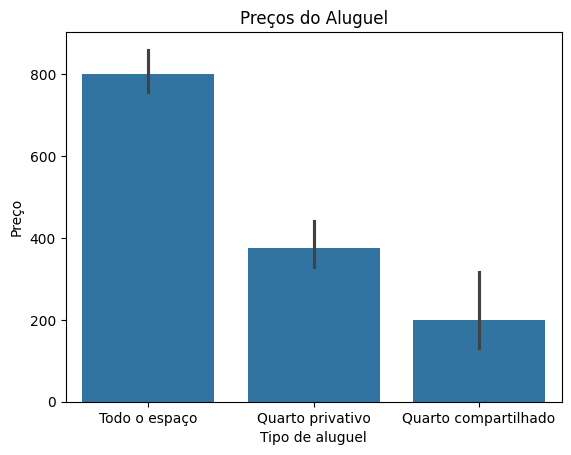

In [19]:
sns.barplot(df_treatment,
            x='room_type',
            y='price_cleaned')


plt.title('Preços do Aluguel')
plt.xlabel('Tipo de aluguel')
plt.ylabel('Preço')
plt.show()

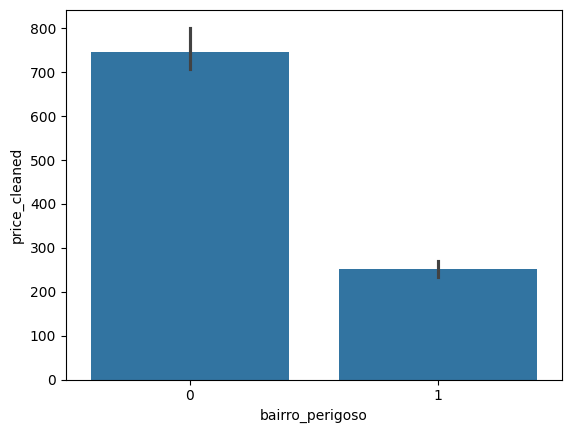

In [20]:
sns.barplot(df_treatment,
            x='bairro_perigoso',
            y='price_cleaned')

plt.show()

- total host
- avg price
- avg number review
- total listing
- gráfico de total de alugueis por bairro e tipo de aluguel
- grafico de numero de reviews
- mapa dos locais
- seleção de rating


- treinar para obter rating?
- treinar para prever preço?

In [21]:
df_treatment.minimum_nights.describe()

count    43068.000000
mean         3.652155
std         15.394401
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       1000.000000
Name: minimum_nights, dtype: float64

In [22]:
# df_treatment.bedrooms = df_treatment.bedrooms.fillna(df_treatment.bedrooms.median())
# df_treatment.beds = df_treatment.beds.fillna(df_treatment.beds.median())
# df_treatment.bathrooms = df_treatment.bathrooms.fillna(df_treatment.bathrooms.median())
# df_treatment.review_scores_rating = df_treatment.review_scores_rating.fillna(0)
df_treatment.host_response_time = df_treatment.host_response_time.fillna("Não informado")

In [23]:
df_treatment.info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      43068 non-null  int64  
 1   name                    43068 non-null  str    
 2   host_name               43057 non-null  str    
 3   host_location           34195 non-null  str    
 4   host_response_time      43068 non-null  str    
 5   host_is_superhost       43068 non-null  bool   
 6   neighbourhood           16330 non-null  str    
 7   neighbourhood_cleansed  43068 non-null  str    
 8   latitude                43068 non-null  float64
 9   longitude               43068 non-null  float64
 10  property_type           43068 non-null  str    
 11  room_type               43046 non-null  str    
 12  accommodates            43068 non-null  int64  
 13  bathrooms               38635 non-null  float64
 14  bedrooms                42096 non-null  float64
 

In [24]:
df_treatment.price_cleaned.describe()

count     38670.000000
mean        717.535325
std        4388.082802
min          30.000000
25%         202.000000
50%         317.000000
75%         565.000000
max      500000.000000
Name: price_cleaned, dtype: float64

**💡 Evidência de Outliers nos Preços**

A distribuição dos preços apresenta fortes indícios de valores discrepantes (outliers):

- Média inflacionada: A média está em 4.388, enquanto o terceiro quartil (75%) é de apenas 565 (ou seja, 75% dos anúncios custam até 565).
- Alta dispersão: O desvio padrão supera o valor do próprio percentil de 75%, mostrando uma variação extrema.
- Máximo discrepante: O valor máximo está excessivamente alto em comparação com o restante dos dados.

Ação: Vamos realizar o corte (trimming) desses outliers acima de 565 para normalizar a análise.

In [25]:
df_treatment = df_treatment[df_treatment["price_cleaned"] <=1000] 
df_treatment.price_cleaned.describe()

count    34359.000000
mean       348.797899
std        211.677365
min         30.000000
25%        193.000000
50%        286.000000
75%        452.000000
max       1000.000000
Name: price_cleaned, dtype: float64

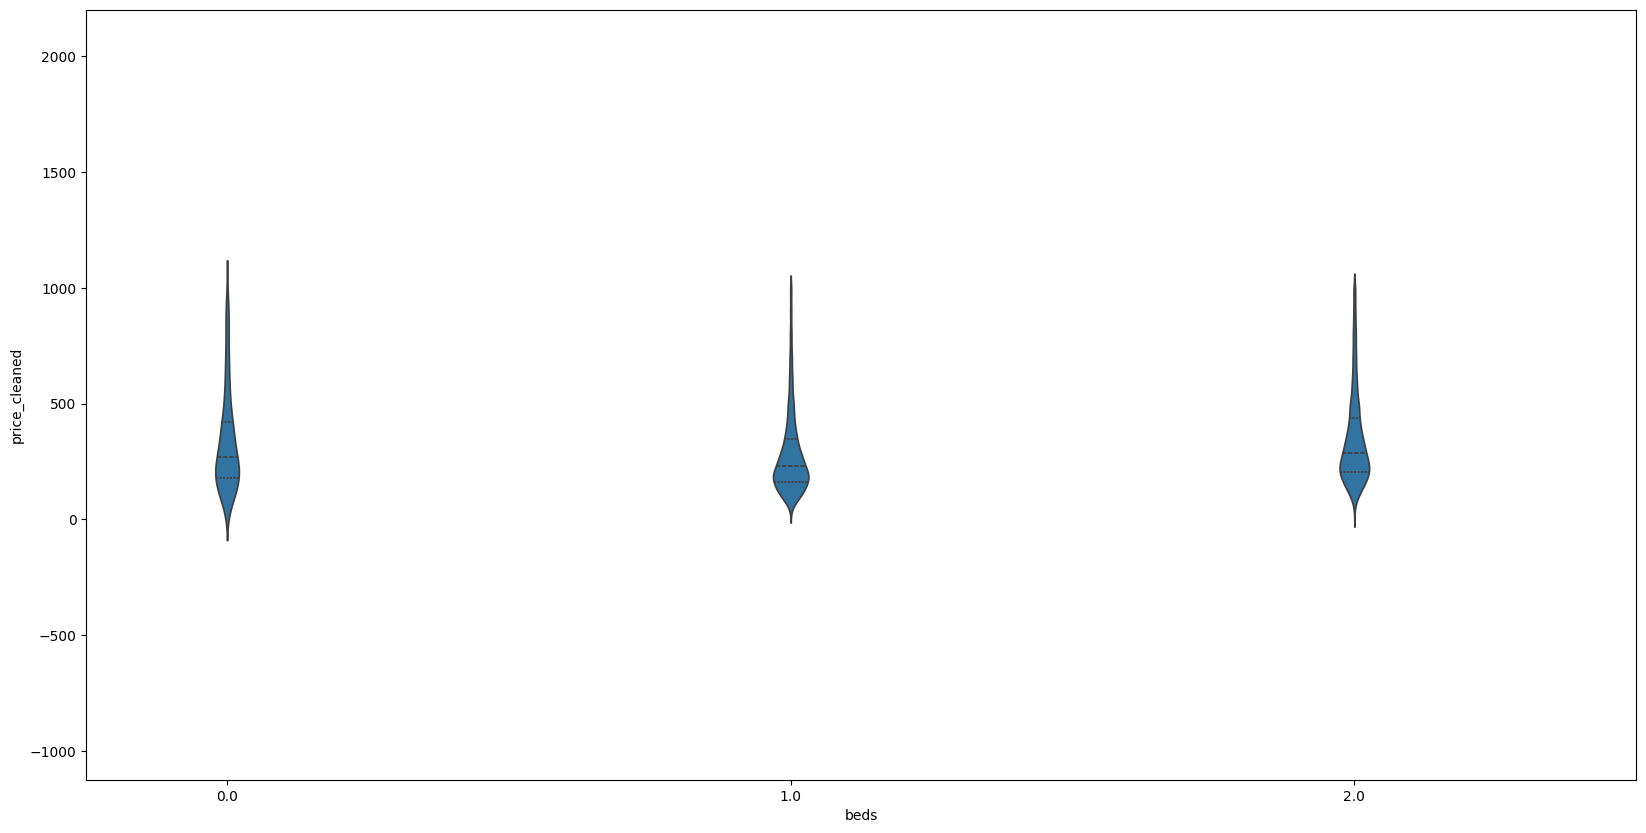

In [26]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
plt.xlim(-0.25,2.5)

plt.show()


0 camas nos anuncios? Provavlemente algum erro dos anuncios, portanto vamos verificar a quantidade que isso ocorre, se o melhor a se fazer é limpar, ou arrumar automaticamente

In [27]:
print("A quantidade de quartos com 0 camas é:", len(df_treatment[df_treatment["beds"] == 0]))

print("A quantidade total de anuncios é:", len(df_treatment))

A quantidade de quartos com 0 camas é: 389
A quantidade total de anuncios é: 34359


Pode ser limpo esses dados sem problemas na análise

In [28]:
df_treatment = df_treatment[df_treatment["beds"]>0]

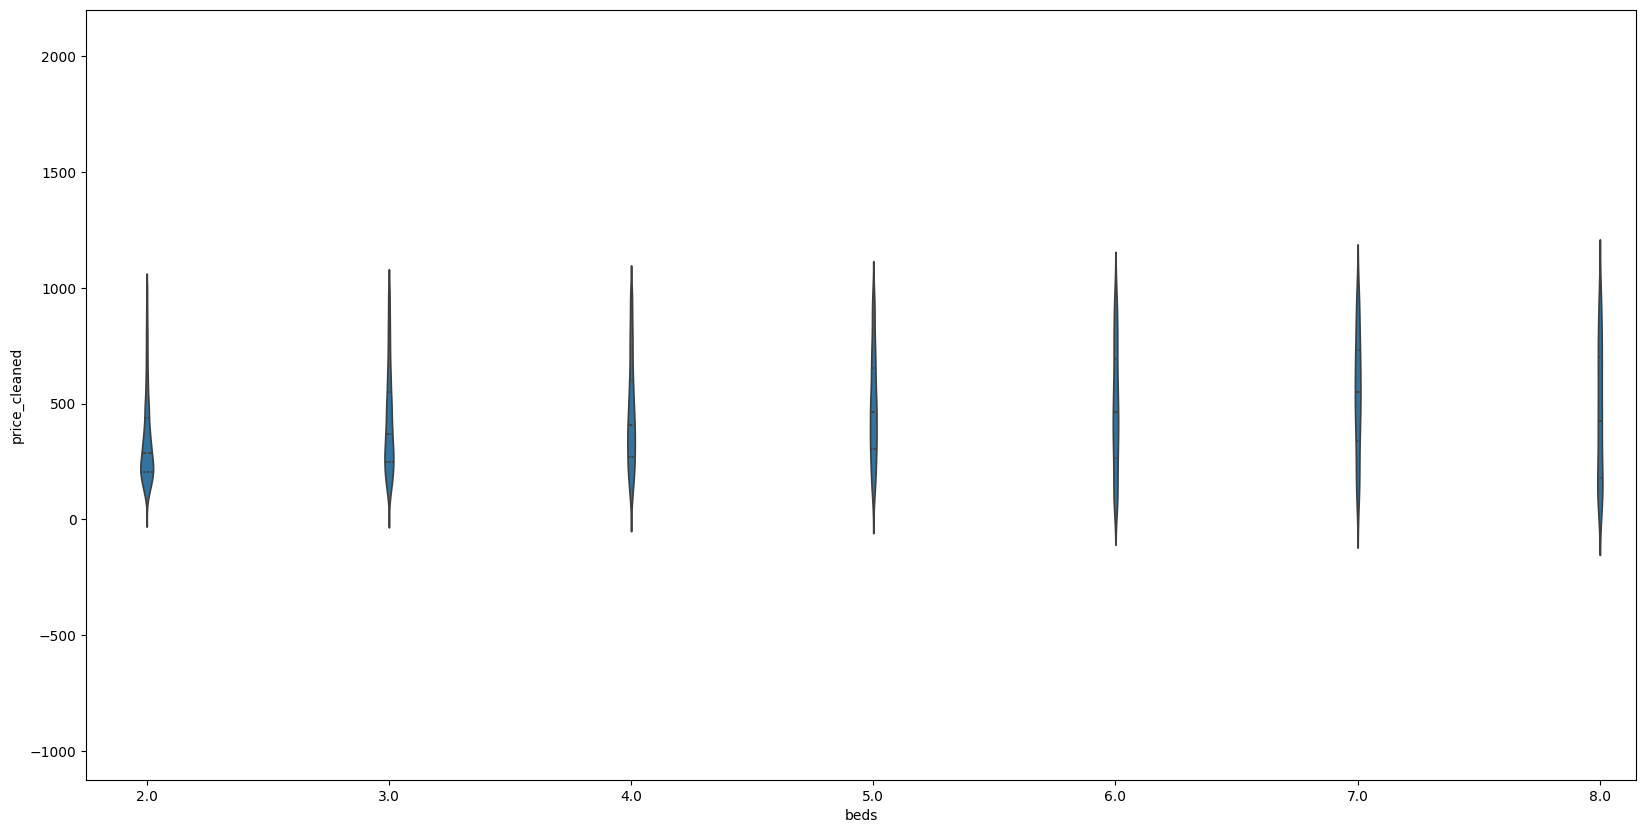

In [29]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="beds", y="price_cleaned", data=df_treatment, inner="quartiles")

# ax.set_yscale("log")
plt.xlim(.75,7.15)

plt.show()


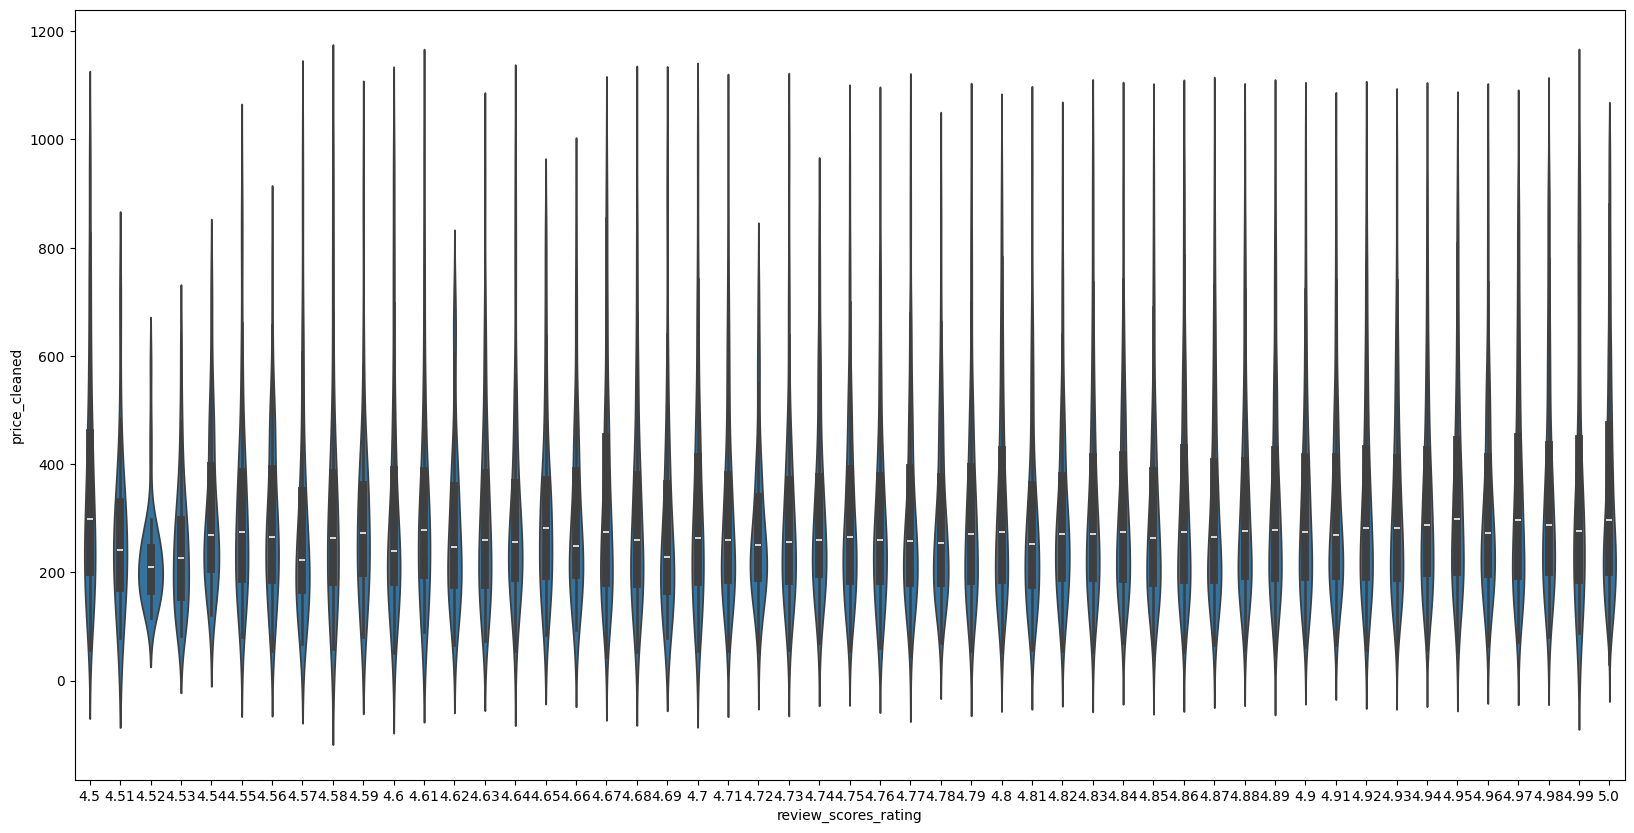

In [30]:
import seaborn as sns

plt.figure(figsize=[20,10])

df_plot_filtrado = df_treatment[
    df_treatment["review_scores_rating"].between(4.5, 5)
]

ax = sns.violinplot(x="review_scores_rating", y="price_cleaned", data=df_plot_filtrado)

# plt.xlim(4,5.1)

plt.show()


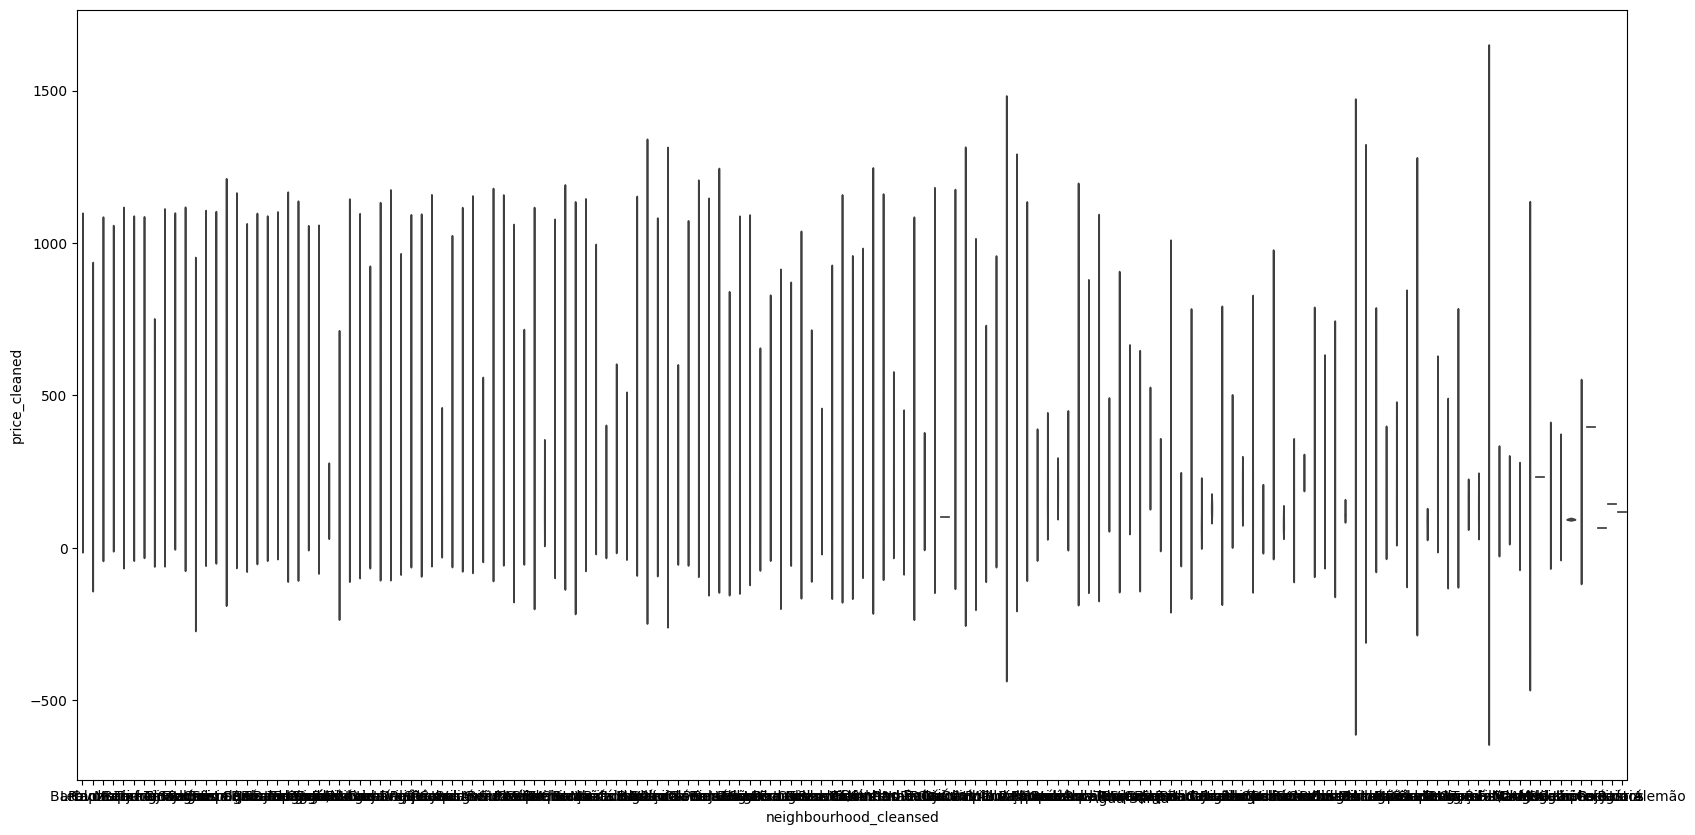

In [31]:
import seaborn as sns

plt.figure(figsize=[20,10])

ax = sns.violinplot(x="neighbourhood_cleansed", y="price_cleaned", data=df_treatment, inner=None)

# ax.set_yscale("log")

plt.show()


In [32]:
df_treatment['bairro_perigoso'].value_counts()

bairro_perigoso
0    31736
1     2223
Name: count, dtype: int64

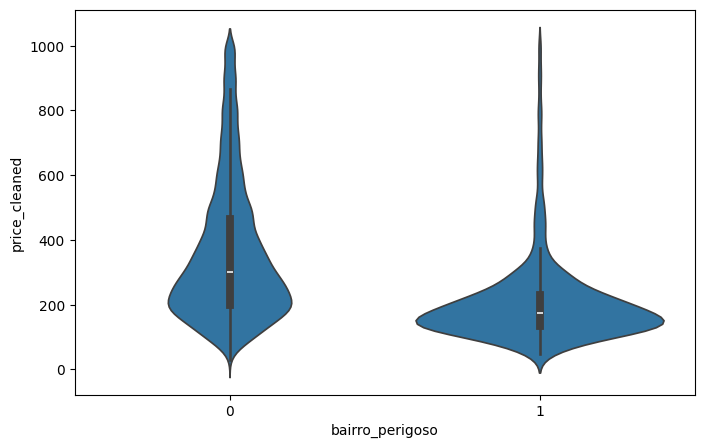

In [33]:
import seaborn as sns

plt.figure(figsize=[8,5])

ax = sns.violinplot(x="bairro_perigoso", y="price_cleaned", data=df_treatment)

# plt.xlim(4,5.1)

plt.show()


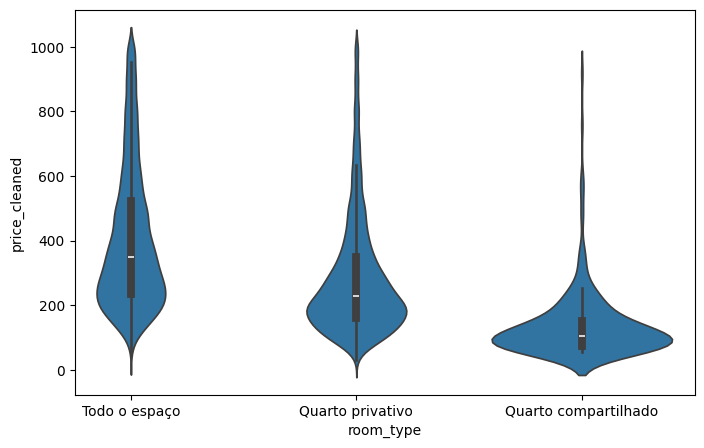

In [48]:
plt.figure(figsize=[8,5])

ax = sns.violinplot(df_treatment, x='room_type', y='price_cleaned')

# ax.set_yscale("log")
plt.xlim(-0.25,2.5)

plt.show()

## Regressão sem Cuidado de Bairros ou Tipo de Quartos


In [118]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import plotly.express as px
RANDOM_SEED = 42

df_arvore_regressora = df_treatment[[
    'id', 'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'room_type', 'review_scores_rating'
    ]].copy()

df_arvore_regressora.dropna(inplace=True)

Primeiro vamos tratar separando os room types

In [119]:
df_arvore_regressora.room_type.value_counts()

room_type
Todo o espaço           16083
Quarto privativo        11673
Quarto compartilhado      183
Name: count, dtype: int64

In [120]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_arvore_regressora[['room_type']])
one_hot = enc.transform(df_arvore_regressora[['room_type']]).toarray()
df_arvore_regressora[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot

Text(0.5, 1.0, 'Correlation Heatmap')

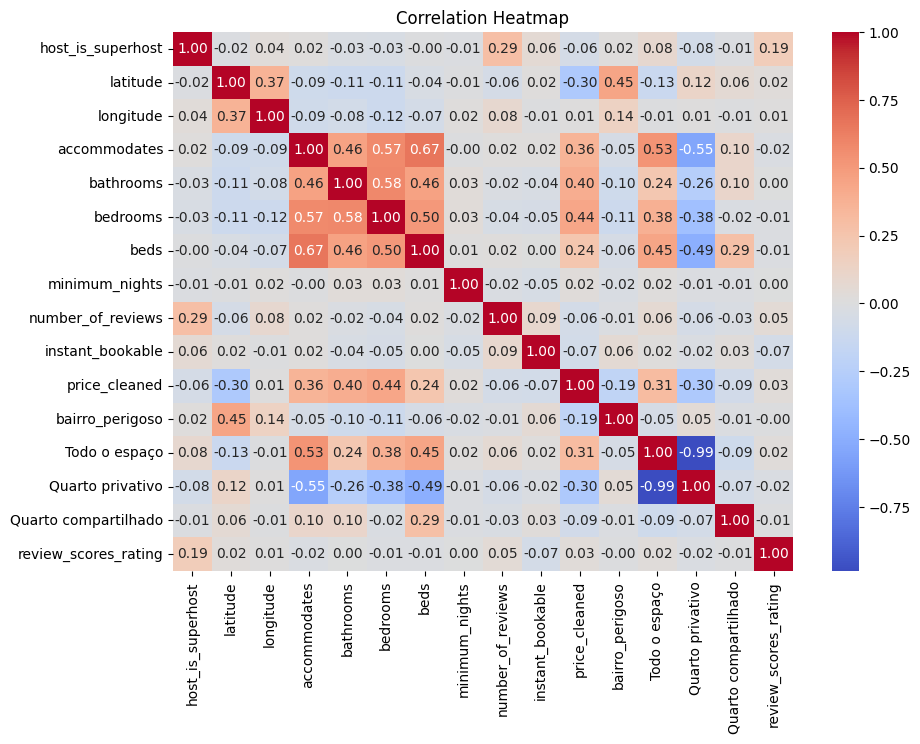

In [121]:
corr = df_arvore_regressora[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado', 'review_scores_rating'
]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

In [122]:
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

In [123]:
X = df_arvore_regressora.drop(columns=['price_cleaned'])
y = df_arvore_regressora['price_cleaned'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [124]:
arvore_regressora = DecisionTreeRegressor(max_depth=10, min_samples_leaf=300)

In [125]:
precomputador = ColumnTransformer(
    transformers=[
        ('cat', preprocessing.OneHotEncoder(sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ],
    remainder='drop')

In [126]:
pipeline_arvore = Pipeline(steps=[
    ('pre-processamento', precomputador),
    ('modelo', arvore_regressora)
])

In [127]:
pipeline_arvore.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre-processamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [128]:
y_pred = pipeline_arvore.predict(X_test)

In [153]:
print("R² Score:", r2_score(y_test, y_pred))
print("Mean squared error:", mean_squared_error(y_test,y_pred))

R² Score: 0.32653837444024314
Mean squared error: 27081.70482507979


In [171]:
from sklearn.dummy import DummyRegressor
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)


print("R² Score do Dummy (Média):", r2_score(y_test, pred_dummy))
print(f"MSE do Dummy (Média): {mean_squared_error(y_test, pred_dummy):.2f}")

R² Score do Dummy (Média): -1.9337404810304548e-05
MSE do Dummy (Média): 40213.47


In [130]:
df_resultados_arvore = pd.DataFrame({
    'id_imovel': X_test['id'],       # Busca o ID original que ficou de fora do treino
    'preço_real': y_test,             # A nota real (Target)
    'preço_previsto': y_pred      # A nota que a árvore calculou
})
df_resultados_arvore.reset_index(drop=True, inplace=True)
df_resultados_arvore['erro'] = (df_resultados_arvore['preço_real'] - df_resultados_arvore['preço_previsto']).abs() / df_resultados_arvore['preço_real'] 


fig = px.line(df_resultados_arvore, y=['preço_real', 'preço_previsto'])
fig.show()
print(df_resultados_arvore[df_resultados_arvore['erro'] >=0.1].head())

             id_imovel  preço_real  preço_previsto      erro
0  1242904250836722226       249.0      299.077951  0.201116
1   608846232315886699       323.0      288.673913  0.106273
3  1199539392037252202       300.0      192.489607  0.358368
4  1416798872967229066       379.0      555.949772  0.466886
5   917562482762750266       147.0      299.077951  1.034544


## Regressão com Cuidado de Bairros ou Tipos de Quartos

In [131]:
# Cria um dicionário onde cada chave é o valor do grupo (0 ou 1) 
# e o valor é o DataFrame correspondente filtrado
dfs_por_bairro = {nome_grupo: dados.drop(columns=['bairro_perigoso']) 
                 for nome_grupo, dados in df_treatment.groupby('bairro_perigoso')}

# Para acessar o DataFrame dos bairros perigosos:
# dfs_por_grupo[1]

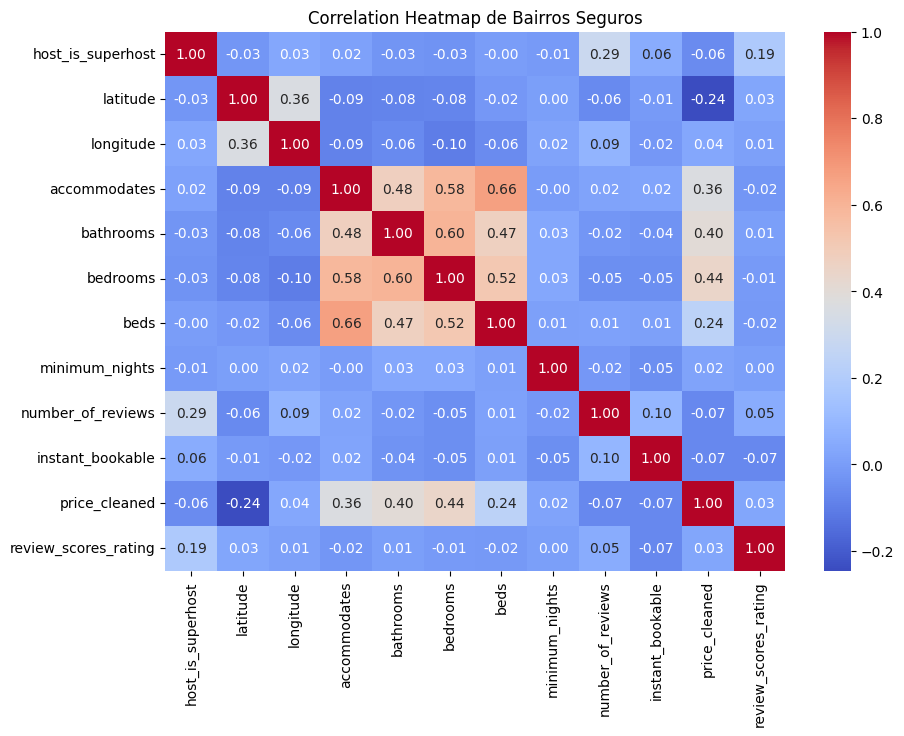

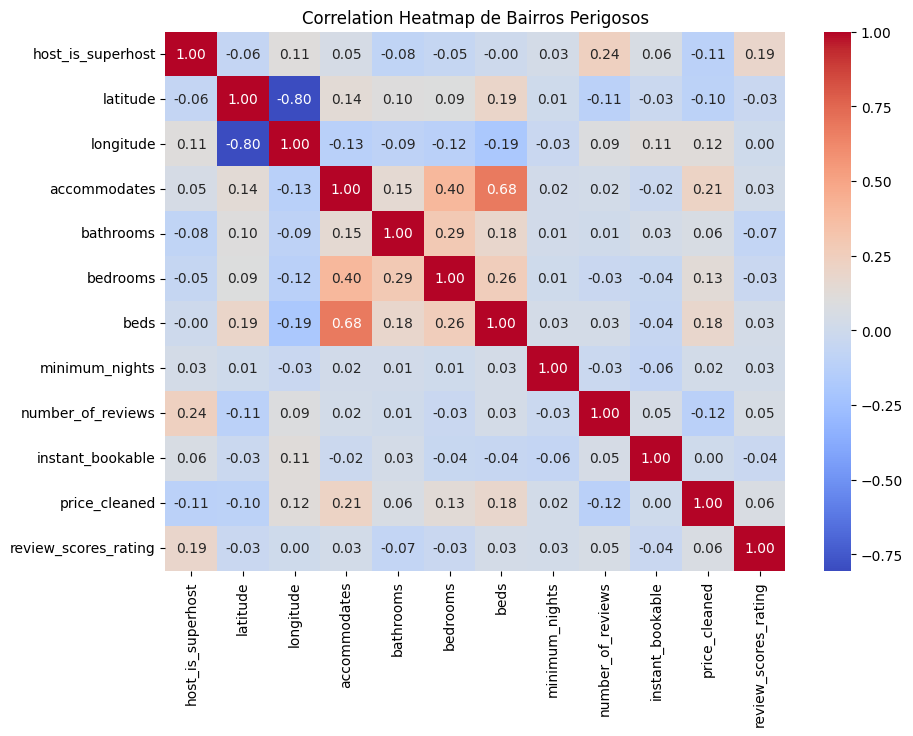

In [132]:
import seaborn as sns
plt.figure(figsize=(10, 7))
corr = dfs_por_bairro[0][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'review_scores_rating'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Seguros')
plt.show()

corr = dfs_por_bairro[1][[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'review_scores_rating'
    # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].dropna().corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap de Bairros Perigosos')
plt.show()

In [133]:

dfs_por_quartos = {nome_grupo: dados.drop(columns=['room_type']) 
                 for nome_grupo, dados in df_treatment.groupby('room_type')}

In [134]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [135]:
# df_treatment é o seu DataFrame
df_treatment.loc[df_treatment['beds'] == 1, 'room_type'] = 'Quarto privativo'

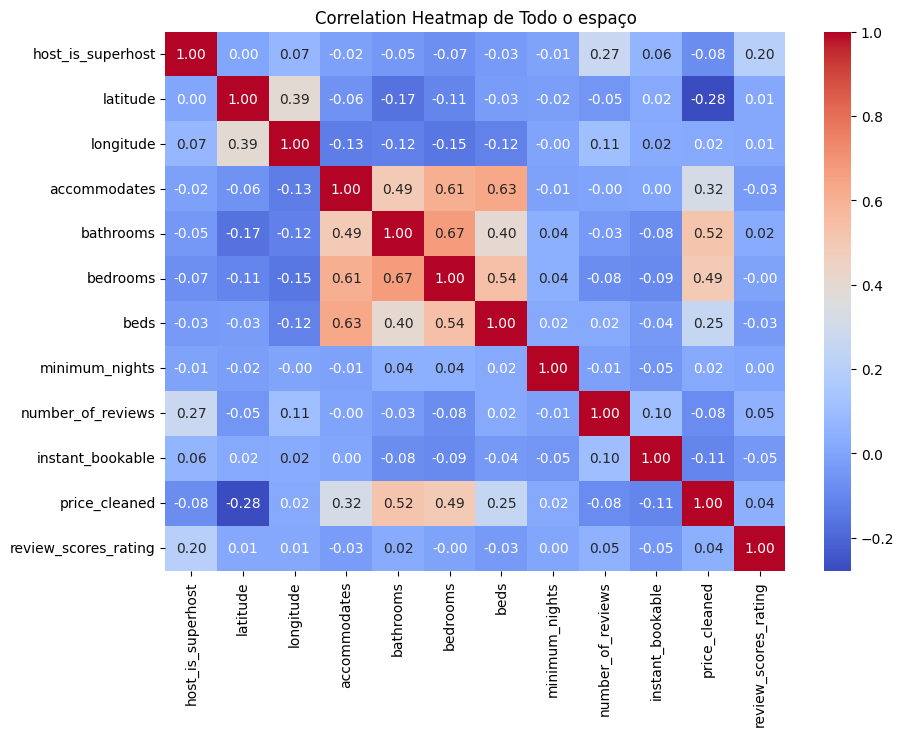

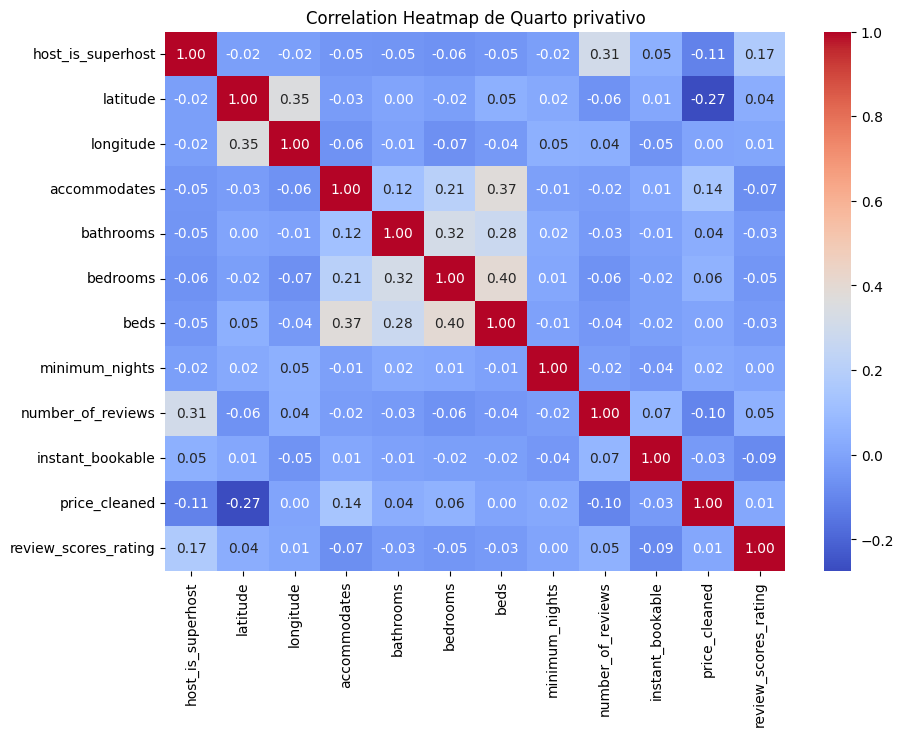

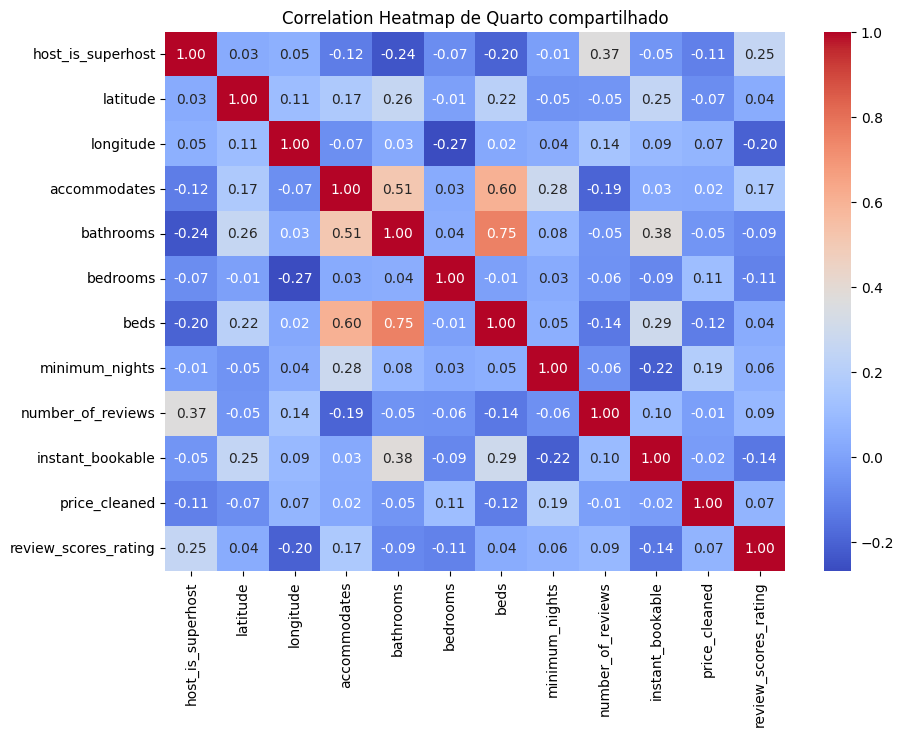

In [136]:
for room in room_trad.values():
    plt.figure(figsize=(10, 7))
    corr = dfs_por_quartos[room][[
        'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
        'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
        'instant_bookable', 'price_cleaned', 'review_scores_rating'
        # 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
        ]].dropna().corr()

    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'Correlation Heatmap de {room}' )
    plt.show()

In [137]:
room_trad.values()

dict_values(['Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'])

In [138]:
df_rating_pred = df_treatment.copy()
df_rating_pred = df_rating_pred.dropna(subset=['room_type'])

In [139]:
df_treatment.room_type.value_counts()

room_type
Todo o espaço           18681
Quarto privativo        15016
Quarto compartilhado      256
Name: count, dtype: int64

### Previsão de Rating

In [140]:
from sklearn.linear_model import SGDRegressor, Lasso
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import preprocessing
import numpy as np
RANDOM_SEED = 42

df_rating_pred = df_rating_pred.dropna()
df_copa = df_rating_pred[df_rating_pred['neighbourhood_cleansed'] == 'Copacabana']
X = df_rating_pred.drop(columns=['review_scores_rating'])
y = df_rating_pred['review_scores_rating'].values
# X = df_copa.drop(columns=['review_scores_rating'])
# y = df_copa['review_scores_rating'].values

In [141]:
X.room_type.value_counts()

room_type
Todo o espaço           6875
Quarto privativo        3984
Quarto compartilhado      61
Name: count, dtype: int64

In [142]:
enc = preprocessing.OneHotEncoder()
enc.fit(df_rating_pred[['room_type']])
# enc.categories_
one_hot = enc.transform(df_rating_pred[['room_type']]).toarray()
# one_hot = enc.transform(df_copa[['room_type']]).toarray()
X[['Quarto compartilhado', 'Quarto privativo', 'Todo o espaço']] = one_hot
cat_cols = ['host_is_superhost', 'bairro_perigoso', 'instant_bookable', 'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado']
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'price_cleaned']

Text(0.5, 1.0, 'Correlation Heatmap')

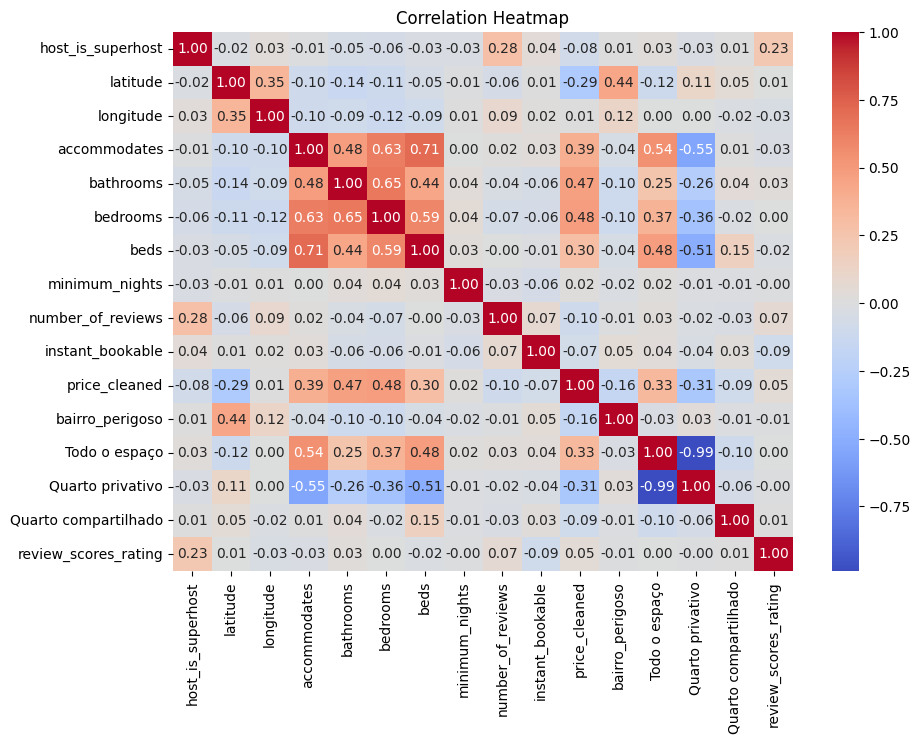

In [143]:
plt.figure(figsize=(10, 7))
X_com_y = X[[
    'host_is_superhost', 'latitude', 'longitude', 'accommodates', 
    'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 
    'instant_bookable', 'price_cleaned', 'bairro_perigoso', 
    'Todo o espaço', 'Quarto privativo', 'Quarto compartilhado'
    ]].copy()

X_com_y['review_scores_rating'] = y

corr = X_com_y.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')